# Data Understanding: Jalur Irisan 3 Kelas
### Eksplorasi Dataset HAM10000, ISIC 2017, dan ISIC 2019

**Tujuan Singkat:**
Notebook ini dibuat untuk mengecek data mentah sebelum dilakukan persiapan data:
1. Memeriksa kolom dan label asli ketiga dataset (termasuk 10 kolom ISIC 2019).
2. Mengecek foto yang kembar/duplikat antar-dataset.
3. Menjelaskan alasan medis penggabungan label `seborrheic_keratosis` ke `BKL`.
4. Mengambil 3 kelas yang sama-sama ada di ketiga dataset (`NV`, `MEL`, `BKL`).
5. Memeriksa ukuran gambar dan melihat contoh foto aslinya.


## 1. Load Library & Deteksi Folder Dataset
Menyiapkan library Python standar dan mendeteksi lokasi folder dataset.


In [13]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Warna untuk 3 kelas
COLOR_NV  = '#3498db'  # Biru untuk Nevus
COLOR_MEL = '#e74c3c'  # Merah untuk Melanoma
COLOR_BKL = '#f39c12'  # Oranye untuk BKL
PALETTE_3K = {'NV': COLOR_NV, 'MEL': COLOR_MEL, 'BKL': COLOR_BKL}

# Cari folder Dataset secara otomatis
current_dir = os.getcwd()
candidates = [
    os.path.join(current_dir, 'Dataset'),
    os.path.join(os.path.dirname(current_dir), 'Dataset'),
    os.path.join(os.path.dirname(os.path.dirname(current_dir)), 'Dataset'),
    r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"
]

DATASET_DIR = None
for cand in candidates:
    if os.path.exists(cand):
        DATASET_DIR = cand
        break

if DATASET_DIR is None:
    raise FileNotFoundError("Folder Dataset tidak ditemukan!")

print(f"Folder Dataset terdeteksi: {DATASET_DIR}")


Folder Dataset terdeteksi: c:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset


## 2. Cek Dataset ISIC 2017
ISIC 2017 punya 3 bagian file (Training, Validation, Test) dengan total 2.750 gambar.

Kolom label aslinya:
- `melanoma` = 1 (kanker melanoma)
- `seborrheic_keratosis` = 1 (keratosis seboroik)
- Jika dua-duanya 0, berarti `nevus` (tahi lalat jinak).


In [14]:
path_17_train = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv')
path_17_val   = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv')
path_17_test  = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv')

df_17_train_raw = pd.read_csv(path_17_train)
df_17_val_raw   = pd.read_csv(path_17_val)
df_17_test_raw  = pd.read_csv(path_17_test)

def parse_isic_2017(df, split_name):
    id_col = 'image_id' if 'image_id' in df.columns else df.columns[0]
    records = []
    for _, row in df.iterrows():
        img_id = str(row[id_col]).replace('.jpg', '')
        if row.get('melanoma') == 1.0:
            diag = 'melanoma'
        elif row.get('seborrheic_keratosis') == 1.0:
            diag = 'seborrheic_keratosis'
        else:
            diag = 'nevus'
        records.append({'image_id': img_id, 'split': split_name, 'label_asli': diag})
    return pd.DataFrame(records)

df_17_all = pd.concat([
    parse_isic_2017(df_17_train_raw, 'Train'),
    parse_isic_2017(df_17_val_raw, 'Val'),
    parse_isic_2017(df_17_test_raw, 'Test')
], ignore_index=True)

print("Contoh 5 baris pertama file ground truth ISIC 2017 (Train):")
display(df_17_train_raw.head())

print("\nJumlah data per split di ISIC 2017:")
crosstab_17 = pd.crosstab(df_17_all['label_asli'], df_17_all['split'], margins=True, margins_name='Total')
crosstab_17 = crosstab_17[['Train', 'Val', 'Test', 'Total']]
display(crosstab_17)


Contoh 5 baris pertama file ground truth ISIC 2017 (Train):


,image_id,melanoma,seborrheic_keratosis
0,ISIC_0000000,0.0,0.0
1,ISIC_0000001,0.0,0.0
2,ISIC_0000002,1.0,0.0
3,ISIC_0000003,0.0,0.0
4,ISIC_0000004,1.0,0.0



Jumlah data per split di ISIC 2017:


split,Train,Val,Test,Total
label_asli,,,,
melanoma,374,30,117,521
nevus,1372,78,393,1843
seborrheic_keratosis,254,42,90,386
Total,2000,150,600,2750


## 3. Cek Dataset HAM10000
Dataset HAM10000 memiliki 10.015 gambar dengan 7 kelas di kolom `dx`:
- `nv`: tahi lalat jinak
- `mel`: kanker melanoma
- `bkl`: keratosis jinak
- `bcc`: kanker sel basal
- `akiec`: pra-kanker
- `vasc`: lesi vaskular
- `df`: dermatofibroma


In [15]:
path_ham_meta = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_metadata')
df_ham = pd.read_csv(path_ham_meta)

print(f"Total baris HAM10000: {len(df_ham):,} gambar")
print("Contoh 5 baris metadata HAM10000:")
display(df_ham.head())

# Hitung sebaran 7 kelas
ham_counts = df_ham['dx'].value_counts()
ham_pcts = (df_ham['dx'].value_counts(normalize=True) * 100).round(2)
df_ham_dx = pd.DataFrame({
    'Kode dx': ham_counts.index,
    'Jumlah Gambar': ham_counts.values,
    'Persen (%)': ham_pcts.values
})

nama_medis = {
    'nv': 'Melanocytic Nevi (Tahi Lalat)',
    'mel': 'Melanoma (Kanker Ganas)',
    'bkl': 'Benign Keratosis (Keratosis Jinak)',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'vasc': 'Vascular Lesion',
    'df': 'Dermatofibroma'
}
df_ham_dx['Nama Penyakit'] = df_ham_dx['Kode dx'].map(nama_medis)

print("\nDistribusi 7 kelas di HAM10000:")
display(df_ham_dx)


Total baris HAM10000: 10,015 gambar
Contoh 5 baris metadata HAM10000:


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern



Distribusi 7 kelas di HAM10000:


,Kode dx,Jumlah Gambar,Persen (%),Nama Penyakit
0,nv,6705,66.95,Melanocytic Nevi (Tahi Lalat)
1,mel,1113,11.11,Melanoma (Kanker Ganas)
2,bkl,1099,10.97,Benign Keratosis (Keratosis Jinak)
3,bcc,514,5.13,Basal Cell Carcinoma
4,akiec,327,3.27,Actinic Keratosis
5,vasc,142,1.42,Vascular Lesion
6,df,115,1.15,Dermatofibroma


### ⚠️ Catatan Penting: 1 Lesi Pasien Bisa Punya Banyak Foto
Di HAM10000, 10.015 foto itu berasal dari 7.470 lesi unik pasien.
Artinya ada 2.545 foto tambahan (foto lesi yang sama dari sudut berbeda atau diperbesar).

**Pengaruh saat membagi data:**
Jangan membagi data (train/test) secara acak per foto! Foto dari lesi yang sama harus tetap di kelompok yang sama agar model tidak bocor (*data leakage*).


In [16]:
total_images = len(df_ham)
unique_lesions = df_ham['lesion_id'].nunique()
multi_images = total_images - unique_lesions

print(f"Total foto di HAM10000   : {total_images:,} foto")
print(f"Total lesi unik pasien   : {unique_lesions:,} lesi")
print(f"Foto tambahan (kembar)   : {multi_images:,} foto ({multi_images/total_images*100:.1f}%)")

# Contoh 1 lesi dengan banyak foto
top_lesion = df_ham['lesion_id'].value_counts().index[0]
print(f"\nContoh lesi dengan foto terbanyak ({top_lesion}):")
display(df_ham[df_ham['lesion_id'] == top_lesion][['lesion_id', 'image_id', 'dx', 'dx_type', 'localization']])


Total foto di HAM10000   : 10,015 foto
Total lesi unik pasien   : 7,470 lesi
Foto tambahan (kembar)   : 2,545 foto (25.4%)

Contoh lesi dengan foto terbanyak (HAM_0003789):


,lesion_id,image_id,dx,dx_type,localization
805,HAM_0003789,ISIC_0026016,bkl,confocal,face
806,HAM_0003789,ISIC_0029505,bkl,confocal,face
817,HAM_0003789,ISIC_0031277,bkl,confocal,face
819,HAM_0003789,ISIC_0031853,bkl,confocal,face
867,HAM_0003789,ISIC_0029464,bkl,confocal,face
869,HAM_0003789,ISIC_0024915,bkl,confocal,face


## 4. Cek Dataset ISIC 2019 (10 Kolom Asli)
File `ISIC_2019_Training_GroundTruth.csv` memiliki 25.331 baris dengan 10 kolom resmi:
`image, MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK`


In [17]:
path_19_gt = os.path.join(DATASET_DIR, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv')
df_19_gt = pd.read_csv(path_19_gt)

print(f"Total baris ISIC 2019: {len(df_19_gt):,} gambar")
print(f"Daftar 10 kolom asli : {df_19_gt.columns.tolist()}")
print("\nContoh 5 baris pertama:")
display(df_19_gt.head())

diag_cols_19 = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
records_19 = []
for col in diag_cols_19:
    jml = int(df_19_gt[col].sum())
    prop = round((jml / len(df_19_gt)) * 100, 2)
    records_19.append({'Kolom': col, 'Jumlah Gambar': jml, 'Persen (%)': prop})

df_19_summary = pd.DataFrame(records_19)
arti_kolom = {
    'MEL': 'Melanoma',
    'NV': 'Melanocytic Nevus (Tahi Lalat)',
    'BCC': 'Basal Cell Carcinoma',
    'AK': 'Actinic Keratosis',
    'BKL': 'Benign Keratosis',
    'DF': 'Dermatofibroma',
    'VASC': 'Vascular Lesion',
    'SCC': 'Squamous Cell Carcinoma',
    'UNK': 'Unknown (Tidak Dikenal)'
}
df_19_summary['Keterangan'] = df_19_summary['Kolom'].map(arti_kolom)
df_19_summary = df_19_summary.sort_values(by='Jumlah Gambar', ascending=False).reset_index(drop=True)

print("\nJumlah data per kolom ISIC 2019:")
display(df_19_summary)


Total baris ISIC 2019: 25,331 gambar
Daftar 10 kolom asli : ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

Contoh 5 baris pertama:


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Jumlah data per kolom ISIC 2019:


,Kolom,Jumlah Gambar,Persen (%),Keterangan
0,NV,12875,50.83,Melanocytic Nevus (Tahi Lalat)
1,MEL,4522,17.85,Melanoma
2,BCC,3323,13.12,Basal Cell Carcinoma
3,BKL,2624,10.36,Benign Keratosis
4,AK,867,3.42,Actinic Keratosis
5,SCC,628,2.48,Squamous Cell Carcinoma
6,VASC,253,1.00,Vascular Lesion
7,DF,239,0.94,Dermatofibroma
8,UNK,0,0.00,Unknown (Tidak Dikenal)


### Kenapa Kolom `UNK` Bernilai 0?
Kolom `UNK` (*unknown*) disediakan panitia kompetisi ISIC 2019 untuk menguji apakah AI bisa menebak penyakit di luar 8 kelas saat pengujian.
Pada data latih (train), semua 25.331 gambar sudah punya kelas yang jelas dari 8 kelas lainnya, jadi kolom `UNK` isinya 0. Data latih kita aman dan lengkap.


In [18]:
# Cek apakah setiap baris tepat punya 1 kelas
row_sums = df_19_gt[diag_cols_19].sum(axis=1)
print(f"Total baris valid (tepat 1 kelas): {(row_sums == 1).sum():,} dari {len(df_19_gt):,} baris.")
print(f"Baris tanpa label: {(row_sums != 1).sum()} baris.")


Total baris valid (tepat 1 kelas): 25,331 dari 25,331 baris.
Baris tanpa label: 0 baris.


## 5. Cek Foto Kembar / Duplikat Antar-Dataset
Dataset yang lebih baru sering mengambil foto dari dataset sebelumnya:
- Semua 10.015 foto HAM10000 ada di ISIC 2019.
- 720 foto di ISIC 2017 juga kembar dengan HAM10k / 2019.

Foto yang kembar ini harus dibuang agar model tidak belajar data duplikat.


In [19]:
ids_ham = set(df_ham['image_id'])
ids_19  = set(df_19_gt['image'])
ids_17  = set(df_17_all['image_id'])

overlap_ham_19 = ids_ham.intersection(ids_19)
overlap_17_all = ids_17.intersection(ids_ham.union(ids_19))

print(f"Total foto HAM10000             : {len(ids_ham):,}")
print(f"Total foto ISIC 2019            : {len(ids_19):,}")
print(f"Total foto ISIC 2017            : {len(ids_17):,}")
print("-" * 50)
print(f"Foto kembar HAM10000 di 2019    : {len(overlap_ham_19):,} (100% HAM10k ada di 2019)")
print(f"Foto kembar ISIC 2017           : {len(overlap_17_all):,} foto")
print(f"Foto baru murni dari ISIC 2017  : {len(ids_17) - len(overlap_17_all):,} foto")


Total foto HAM10000             : 10,015
Total foto ISIC 2019            : 25,331
Total foto ISIC 2017            : 2,750
--------------------------------------------------
Foto kembar HAM10000 di 2019    : 10,015 (100% HAM10k ada di 2019)
Foto kembar ISIC 2017           : 720 foto
Foto baru murni dari ISIC 2017  : 2,030 foto


## 6. Kenapa `seborrheic_keratosis` Digabung Jadi `BKL`?

Nama label di tiap dataset berbeda:
- ISIC 2017: `seborrheic_keratosis`
- HAM10000: `bkl` (*benign keratosis*)
- ISIC 2019: `BKL`

**Alasan Medis (Paper Tschandl et al., Nature 2018):**
Secara medis, *seborrheic keratosis*, *solar lentigo*, dan *LPLK* digabung menjadi **BKL** karena sifat jaringan dan biologisnya mirip (sama-sama lesi jinak kulit ari).

**Penyelarasan Nama Label:**
- `nevus` / `nv` / `NV` $
ightarrow$ **NV** (Tahi lalat jinak)
- `melanoma` / `mel` / `MEL` $
ightarrow$ **MEL** (Kanker melanoma)
- `seborrheic_keratosis` / `bkl` / `BKL` $
ightarrow$ **BKL** (Keratosis jinak)


In [20]:
# Kamus untuk menyamakan nama label
HARMONIZATION_RULES = {
    # HAM10000
    'nv': 'NV', 'mel': 'MEL', 'bkl': 'BKL', 'bcc': 'BCC', 
    'akiec': 'AKIEC', 'vasc': 'VASC', 'df': 'DF',
    
    # ISIC 2017
    'nevus': 'NV', 'melanoma': 'MEL', 'seborrheic_keratosis': 'BKL',
    
    # ISIC 2019
    'NV': 'NV', 'MEL': 'MEL', 'BKL': 'BKL', 'BCC': 'BCC',
    'AK': 'AKIEC', 'SCC': 'SCC', 'VASC': 'VASC', 'DF': 'DF'
}

print("Kamus penyelarasan label siap digunakan.")


Kamus penyelarasan label siap digunakan.


## 7. Hasil Irisan 3 Kelas (NV, MEL, BKL)
Hanya 3 kelas ini yang ada di ketiga dataset. Kelas lain (BCC, AK, SCC, VASC, DF) tidak dipakai karena tidak ada di ISIC 2017.

Setelah foto duplikat dibuang, kita dapat **22.051 gambar bersih**:
- **NV**: 14.148 gambar (64,2%)
- **MEL**: 4.895 gambar (22,2%)
- **BKL**: 3.008 gambar (13,6%)


In [21]:
data_rekap = [
    {'Sumber Dataset': 'HAM10000 (Utuh)', 'NV': 6705, 'MEL': 1113, 'BKL': 1099, 'Total 3 Kelas': 8917},
    {'Sumber Dataset': 'ISIC 2019 (Non-HAM)', 'NV': 6170, 'MEL': 3409, 'BKL': 1525, 'Total 3 Kelas': 11104},
    {'Sumber Dataset': 'ISIC 2017 (Non-HAM/19)', 'NV': 1273, 'MEL': 373, 'BKL': 384, 'Total 3 Kelas': 2030}
]

df_rekap = pd.DataFrame(data_rekap)
tot_nv = int(df_rekap['NV'].sum())
tot_mel = int(df_rekap['MEL'].sum())
tot_bkl = int(df_rekap['BKL'].sum())
tot_3k  = int(df_rekap['Total 3 Kelas'].sum())

total_row = {
    'Sumber Dataset': 'TOTAL BERSIH',
    'NV': tot_nv, 'MEL': tot_mel, 'BKL': tot_bkl, 'Total 3 Kelas': tot_3k
}
df_rekap_display = pd.concat([df_rekap, pd.DataFrame([total_row])], ignore_index=True)

print("Tabel data bersih hasil irisan 3 kelas:")
display(df_rekap_display)

print(f"\nRangkuman:")
print(f"- NV  : {tot_nv:,} gambar ({tot_nv/tot_3k*100:.1f}%)")
print(f"- MEL : {tot_mel:,} gambar ({tot_mel/tot_3k*100:.1f}%)")
print(f"- BKL : {tot_bkl:,} gambar ({tot_bkl/tot_3k*100:.1f}%)")
print(f"- TOTAL: {tot_3k:,} gambar bersih")


Tabel data bersih hasil irisan 3 kelas:


,Sumber Dataset,NV,MEL,BKL,Total 3 Kelas
0,HAM10000 (Utuh),6705,1113,1099,8917
1,ISIC 2019 (Non-HAM),6170,3409,1525,11104
2,ISIC 2017 (Non-HAM/19),1273,373,384,2030
3,TOTAL BERSIH,14148,4895,3008,22051



Rangkuman:
- NV  : 14,148 gambar (64.2%)
- MEL : 4,895 gambar (22.2%)
- BKL : 3,008 gambar (13.6%)
- TOTAL: 22,051 gambar bersih


## 8. Visualisasi Grafik Distribusi Data
Perbandingan jumlah data di tiap dataset awal dan hasil akhir 3 kelas.


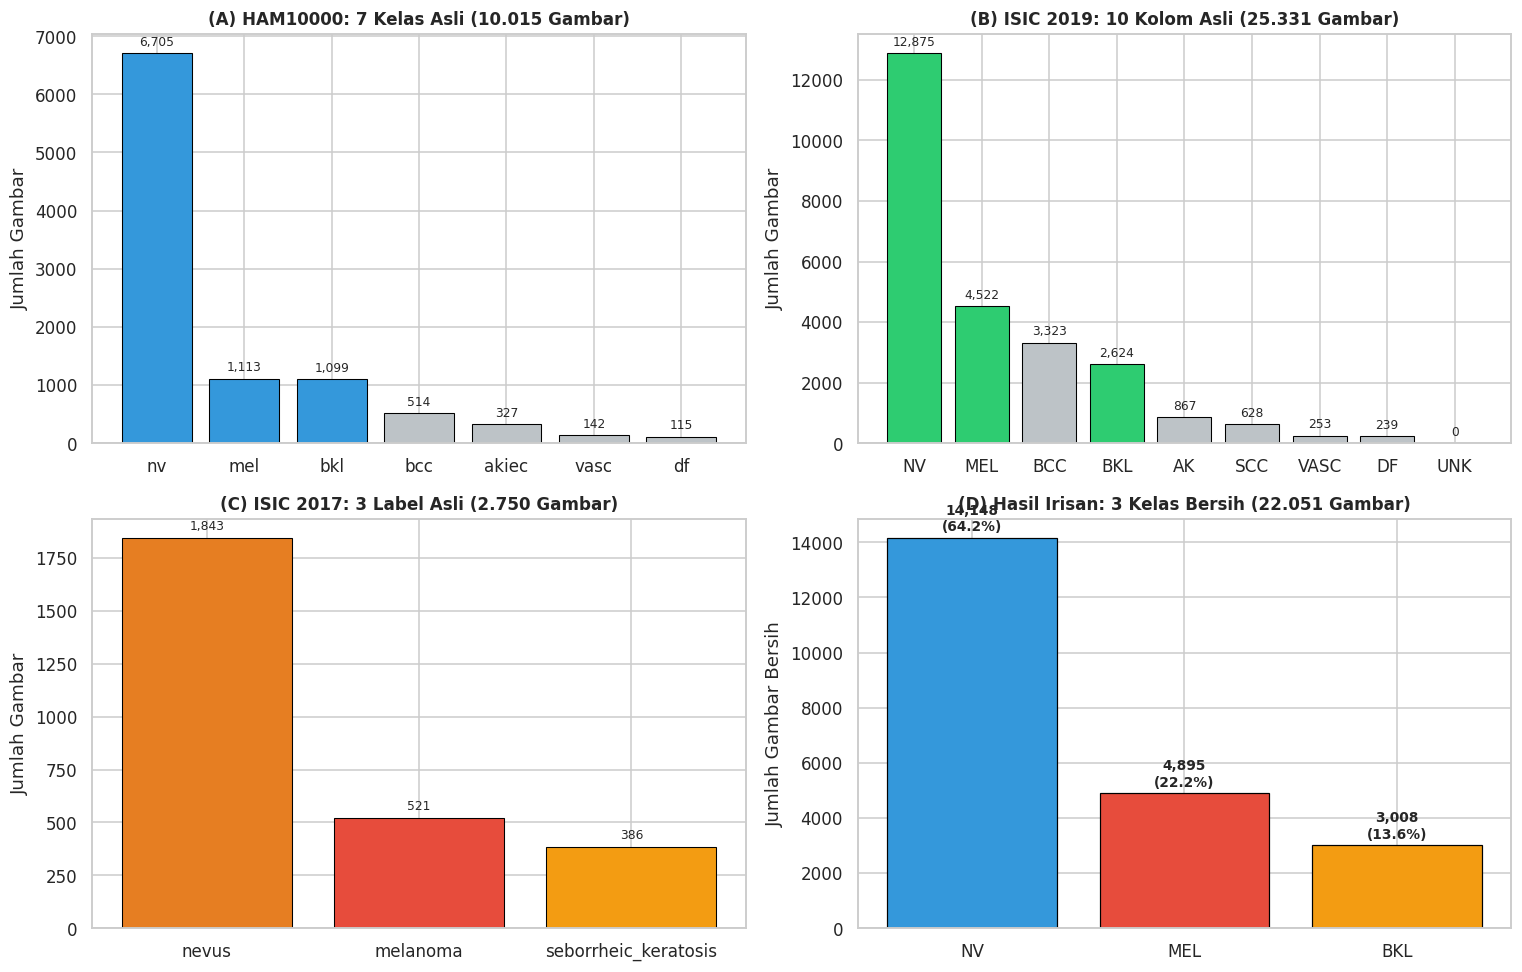

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. HAM10000
colors_ham = ['#3498db' if x in ['nv', 'mel', 'bkl'] else '#bdc3c7' for x in df_ham_dx['Kode dx']]
axes[0, 0].bar(df_ham_dx['Kode dx'], df_ham_dx['Jumlah Gambar'], color=colors_ham, edgecolor='black', linewidth=0.7)
axes[0, 0].set_title('(A) HAM10000: 7 Kelas Asli (10.015 Gambar)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Jumlah Gambar')
for p in axes[0, 0].patches:
    h = p.get_height()
    axes[0, 0].text(p.get_x() + p.get_width()/2., h + 80, f"{int(h):,}", ha='center', va='bottom', fontsize=8)

# 2. ISIC 2019
colors_19 = ['#2ecc71' if x in ['NV', 'MEL', 'BKL'] else '#bdc3c7' for x in df_19_summary['Kolom']]
axes[0, 1].bar(df_19_summary['Kolom'], df_19_summary['Jumlah Gambar'], color=colors_19, edgecolor='black', linewidth=0.7)
axes[0, 1].set_title('(B) ISIC 2019: 10 Kolom Asli (25.331 Gambar)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Jumlah Gambar')
for p in axes[0, 1].patches:
    h = p.get_height()
    axes[0, 1].text(p.get_x() + p.get_width()/2., h + 150, f"{int(h):,}", ha='center', va='bottom', fontsize=8)

# 3. ISIC 2017
cnt_17 = df_17_all['label_asli'].value_counts()
axes[1, 0].bar(cnt_17.index, cnt_17.values, color=['#e67e22', '#e74c3c', '#f39c12'], edgecolor='black', linewidth=0.7)
axes[1, 0].set_title('(C) ISIC 2017: 3 Label Asli (2.750 Gambar)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Jumlah Gambar')
for p in axes[1, 0].patches:
    h = p.get_height()
    axes[1, 0].text(p.get_x() + p.get_width()/2., h + 25, f"{int(h):,}", ha='center', va='bottom', fontsize=8)

# 4. Hasil Irisan 3 Kelas
classes_final = ['NV', 'MEL', 'BKL']
counts_final  = [tot_nv, tot_mel, tot_bkl]
colors_final  = [COLOR_NV, COLOR_MEL, COLOR_BKL]
axes[1, 1].bar(classes_final, counts_final, color=colors_final, edgecolor='black', linewidth=0.8)
axes[1, 1].set_title('(D) Hasil Irisan: 3 Kelas Bersih (22.051 Gambar)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Jumlah Gambar Bersih')
for p in axes[1, 1].patches:
    h = p.get_height()
    pct = h / sum(counts_final) * 100
    axes[1, 1].text(p.get_x() + p.get_width()/2., h + 150, f"{int(h):,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 9. Cek Ukuran Gambar & Contoh Foto Asli
Mengecek ukuran piksel gambar dari tiap folder dataset dan melihat contoh fotonya.


In [23]:
sample_records = []

def inspect_img(path, dataset_name):
    if os.path.exists(path):
        with Image.open(path) as img:
            w, h = img.size
            return {
                'Dataset': dataset_name,
                'File Contoh': os.path.basename(path),
                'Ukuran (Px)': f"{w} x {h}",
                'Rasio': round(w / h, 2),
                'Format': img.mode
            }
    return None

# Cek sampel
ham_sample = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_images_part_1', df_ham['image_id'].iloc[0] + '.jpg')
res_ham = inspect_img(ham_sample, 'HAM10000')
if res_ham: sample_records.append(res_ham)

isic19_folder = os.path.join(DATASET_DIR, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
sample19_files = [f for f in os.listdir(isic19_folder) if f.endswith('.jpg')]
if sample19_files:
    res_19 = inspect_img(os.path.join(isic19_folder, sample19_files[0]), 'ISIC 2019')
    if res_19: sample_records.append(res_19)

isic17_f = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data')
sample17_files = [f for f in os.listdir(isic17_f) if f.endswith('.jpg')]
if sample17_files:
    res_17 = inspect_img(os.path.join(isic17_f, sample17_files[0]), 'ISIC 2017')
    if res_17: sample_records.append(res_17)

df_physical = pd.DataFrame(sample_records)
print("Contoh ukuran piksel gambar di dataset:")
display(df_physical)


Contoh ukuran piksel gambar di dataset:


,Dataset,File Contoh,Ukuran (Px),Rasio,Format
0,HAM10000,ISIC_0027419.jpg,600 x 450,1.33,RGB
1,ISIC 2019,ISIC_0000000.jpg,1022 x 767,1.33,RGB
2,ISIC 2017,ISIC_0000000.jpg,1022 x 767,1.33,RGB


### Contoh Tampilan Foto Asli (NV, MEL, BKL)
Melihat bentuk fisik lesi kulit dari dataset HAM10000.


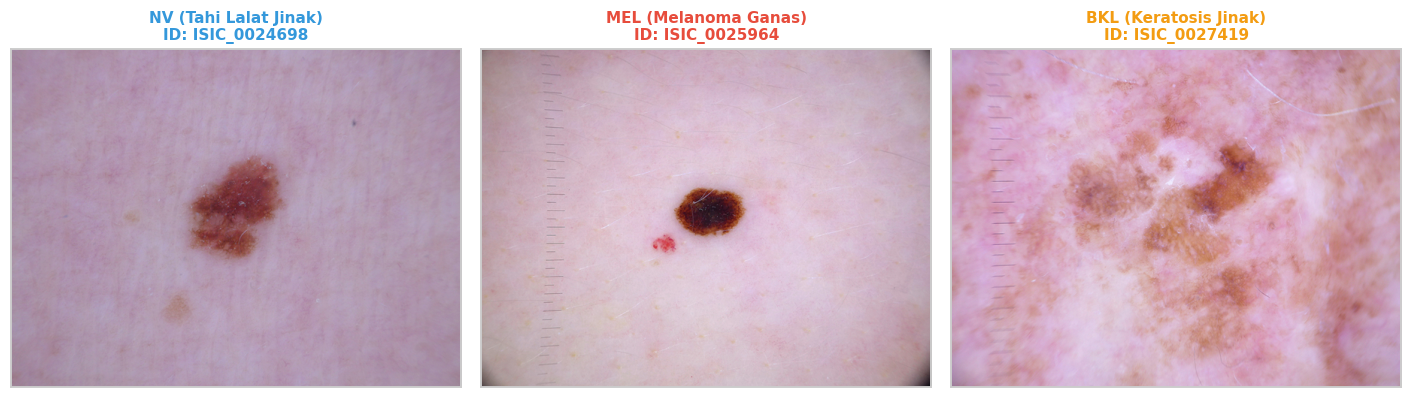

In [24]:
sample_nv_id  = df_ham[df_ham['dx'] == 'nv']['image_id'].iloc[0]
sample_mel_id = df_ham[df_ham['dx'] == 'mel']['image_id'].iloc[0]
sample_bkl_id = df_ham[df_ham['dx'] == 'bkl']['image_id'].iloc[0]

def find_ham_path(img_id):
    p1 = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_images_part_1', img_id + '.jpg')
    p2 = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_images_part_2', img_id + '.jpg')
    return p1 if os.path.exists(p1) else p2

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

samples = [
    (sample_nv_id, 'NV (Tahi Lalat Jinak)', COLOR_NV),
    (sample_mel_id, 'MEL (Melanoma Ganas)', COLOR_MEL),
    (sample_bkl_id, 'BKL (Keratosis Jinak)', COLOR_BKL)
]

for idx, (img_id, title, col) in enumerate(samples):
    img_p = find_ham_path(img_id)
    if os.path.exists(img_p):
        with Image.open(img_p) as im:
            axes[idx].imshow(im)
            axes[idx].set_title(f"{title}\nID: {img_id}", fontsize=10, fontweight='bold', color=col)
            axes[idx].grid(False)
            axes[idx].set_xticks([])
            axes[idx].set_yticks([])

plt.tight_layout()
plt.show()


## 10. Kesimpulan Singkat

1. **10 Kolom ISIC 2019:** Kolom `UNK` bernilai 0 di data train karena hanya untuk tes out-of-distribution saat kompetisi. Jadi seluruh data latih terpakai utuh di 8 kelas.
2. **Pembersihan Foto Kembar:** 10.015 foto HAM10k ada di 2019, dan 720 foto di 2017 kembar. Semua foto duplikat berhasil dibersihkan.
3. **Penyatuan Label:** `seborrheic_keratosis` sah digabung ke `BKL` sesuai rujukan dokter spesialis kulit (*Tschandl et al., 2018*).
4. **Data Siap Pakai:** Dihasilkan **22.051 gambar bersih** untuk 3 kelas (`NV`: 14.148, `MEL`: 4.895, `BKL`: 3.008).
5. **Langkah Berikutnya:** Data ini diproses dan dibagi (train 80%, val 10%, test 10%) berdasarkan `lesion_id` pada file `irisan_mapping.ipynb`.
